# BU MET CS 677 Final Project 2024

By Michael Kwok

**Goal:**

Predict whether tomorrow's stock price will be up or down based on features derived from daily price attributes (open, high, low, close)

**Dataset:**

https://www.nasdaq.com/market-activity/etf/spy/historical?page=1&rows_per_page=10&timeline=y10

# Table of contents

1. Data import

2. Column creation

3. Train/test split

4. Exploratory data analysis

5. MODEL: Logistic regression

6. MODEL: K-nearest neighbors

7. MODEL: Naive bayes

8. MODEL: Decision tree

9. MODEL: Random forest

10. MODEL: Support vector machine

11. Summary table

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Data import

In [2]:
df = pd.read_csv('SPY_oct_22_2024.csv')
df = df.loc[::-1].reset_index(drop=True) # ensure table is ascending order
df['Date'] = pd.to_datetime(df['Date'])
df['Weekday'] = df['Date'].dt.weekday
df.set_index('Date', inplace=True)
df.rename(columns={'Close/Last': 'Close'}, inplace=True)

df

,Close,Volume,Open,High,Low,Weekday
Date,,,,,,
2014-10-22,192.69,151377900,194.41,194.91,192.6100,2
2014-10-23,194.93,153664900,194.62,196.20,194.2600,3
2014-10-24,196.43,116715200,195.25,196.49,194.4900,4
2014-10-27,196.16,82747540,195.73,196.45,195.0300,0
2014-10-28,198.41,105847800,196.82,198.42,196.7300,1
...,...,...,...,...,...,...
2024-10-15,579.78,54203640,584.59,584.90,578.5450,1
2024-10-16,582.30,30725440,579.78,582.83,578.9600,2
2024-10-17,582.35,34393710,585.91,586.12,582.1600,3


# 2. Column creation

Features and target

In [3]:
# create features
df['High_to_close'] = df['Close'] / df['High'] - 1
df['Low_to_close'] = df['Close'] / df['Low'] - 1
df['High_to_low'] = df['High'] / df['Low'] - 1
df['Open_to_high'] = df['High'] / df['Open'] - 1
df['Open_to_low'] = df['Low'] / df['Open'] - 1
df['Open_to_close'] = df['Close'] / df['Open'] - 1
df['Close_to_close'] = df['Close'] / df['Close'].shift(1) - 1
df['Close_to_open'] = df['Open'] / df['Close'].shift(1) - 1

# create target
df['Next_day_up'] = df['Close_to_close'].shift(-1)
df['Next_day_up'] = np.where(df['Next_day_up']>0, 1, 0)

df

,Close,Volume,Open,High,Low,Weekday,High_to_close,Low_to_close,High_to_low,Open_to_high,Open_to_low,Open_to_close,Close_to_close,Close_to_open,Next_day_up
Date,,,,,,,,,,,,,,,
2014-10-22,192.69,151377900,194.41,194.91,192.6100,2,-0.011390,0.000415,0.011941,0.002572,-0.009259,-0.008847,NaN,NaN,1
2014-10-23,194.93,153664900,194.62,196.20,194.2600,3,-0.006473,0.003449,0.009987,0.008118,-0.001850,0.001593,0.011625,0.010016,1
2014-10-24,196.43,116715200,195.25,196.49,194.4900,4,-0.000305,0.009975,0.010283,0.006351,-0.003892,0.006044,0.007695,0.001642,0
2014-10-27,196.16,82747540,195.73,196.45,195.0300,0,-0.001476,0.005794,0.007281,0.003679,-0.003576,0.002197,-0.001375,-0.003564,1
2014-10-28,198.41,105847800,196.82,198.42,196.7300,1,-0.000050,0.008540,0.008590,0.008129,-0.000457,0.008078,0.011470,0.003365,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-10-15,579.78,54203640,584.59,584.90,578.5450,1,-0.008754,0.002135,0.010984,0.000530,-0.010341,-0.008228,-0.007770,0.000462,1
2024-10-16,582.30,30725440,579.78,582.83,578.9600,2,-0.000909,0.005769,0.006684,0.005261,-0.001414,0.004346,0.004346,0.000000,1
2024-10-17,582.35,34393710,585.91,586.12,582.1600,3,-0.006432,0.000326,0.006802,0.000358,-0.006400,-0.006076,0.000086,0.006200,1


In [4]:
FEATURES = ['Weekday','High_to_close','Low_to_close','High_to_low','Open_to_high','Open_to_low','Open_to_close','Close_to_close','Close_to_open']

TARGET = 'Next_day_up'

print(len(FEATURES), 'features,', df[TARGET].nunique(), 'class labels')

9 features, 2 class labels


# 3. Train/test split

In [5]:
from sklearn.model_selection import train_test_split

df.dropna(inplace=True)

X = df[FEATURES]
y = df[[TARGET]]

# split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)

# 4. Exploratory data analysis

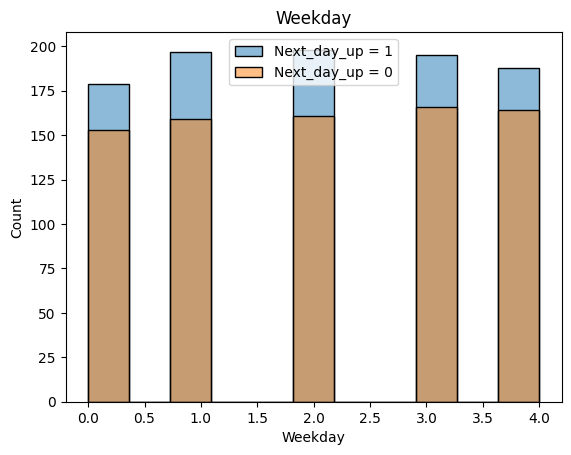

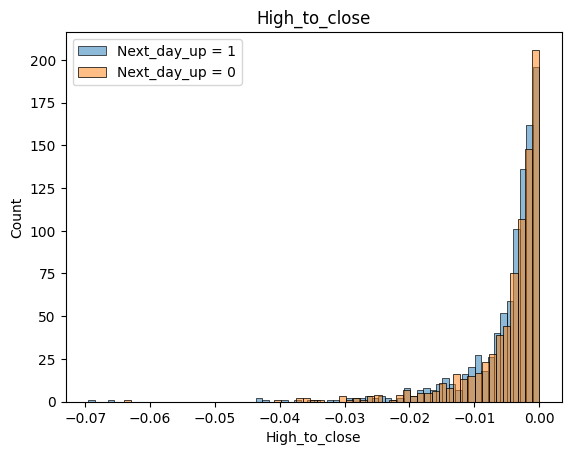

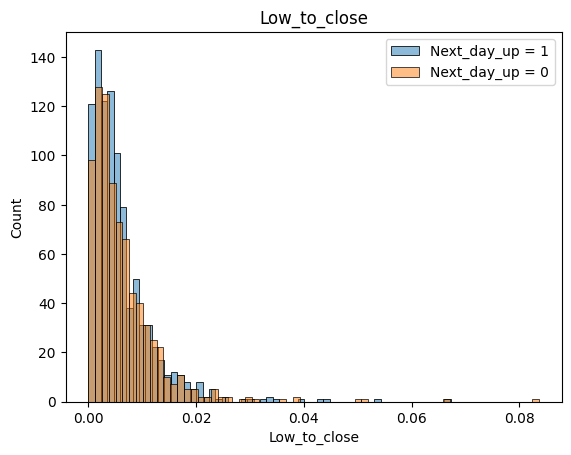

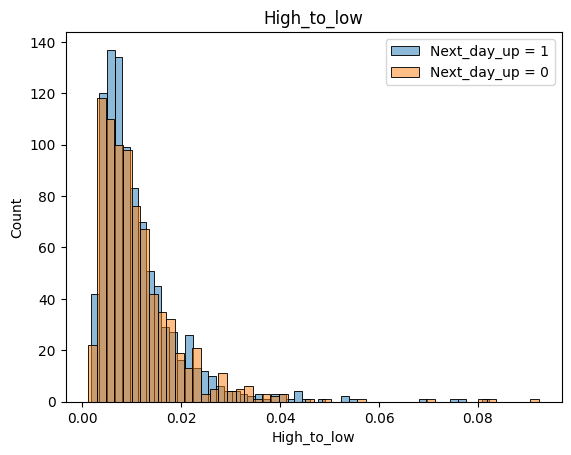

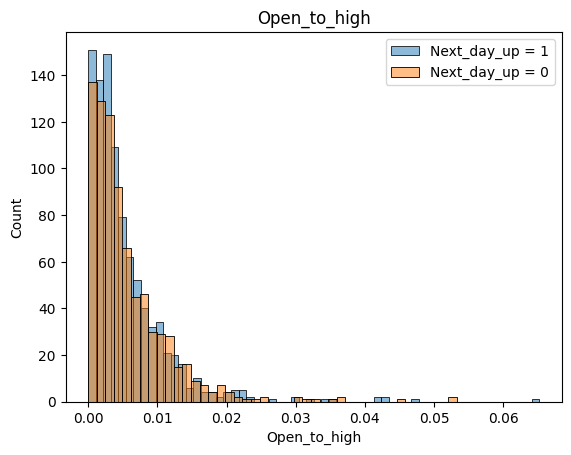

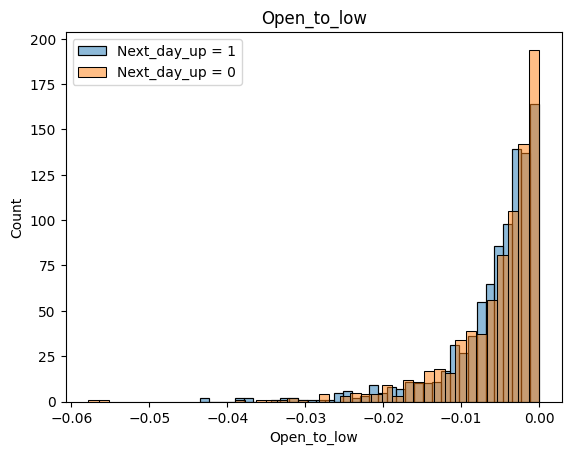

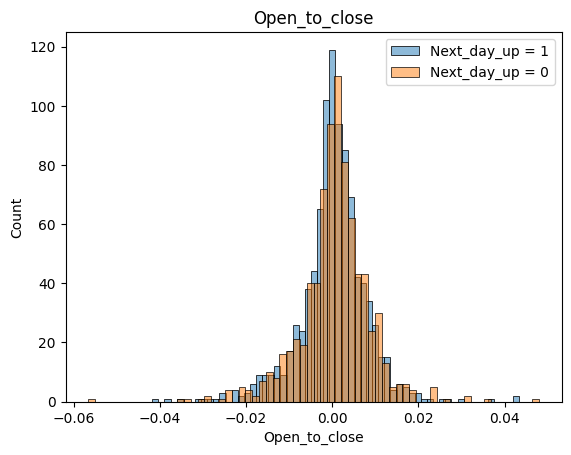

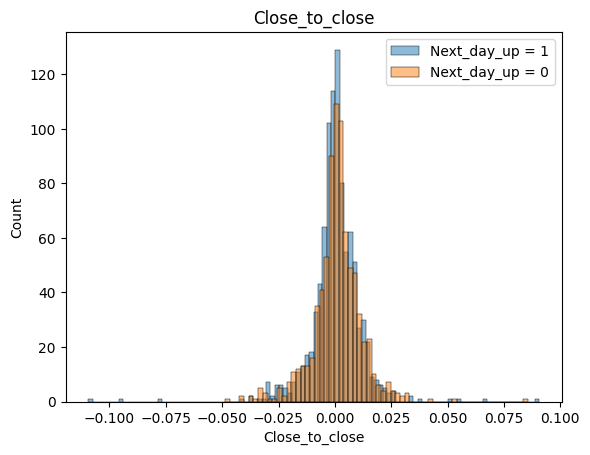

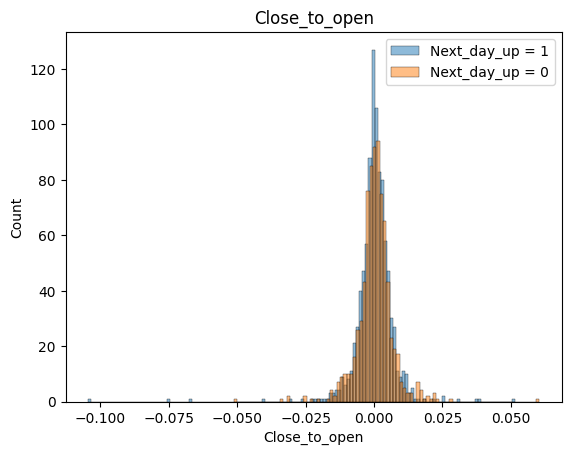

In [6]:
# feature histograms by target class

all_train = X_train.copy()
all_train[TARGET] = y_train

for feature in FEATURES:
    
    for class_ in y_train[TARGET].unique():
        sns.histplot(all_train[all_train[TARGET]==class_][feature], alpha=0.5)

    plt.title(feature)
    plt.legend([f'{TARGET} = {x}' for x in y_train[TARGET].unique()])
    plt.show()

Analysis of the above: none of the features have a clear distinction when separated by target class

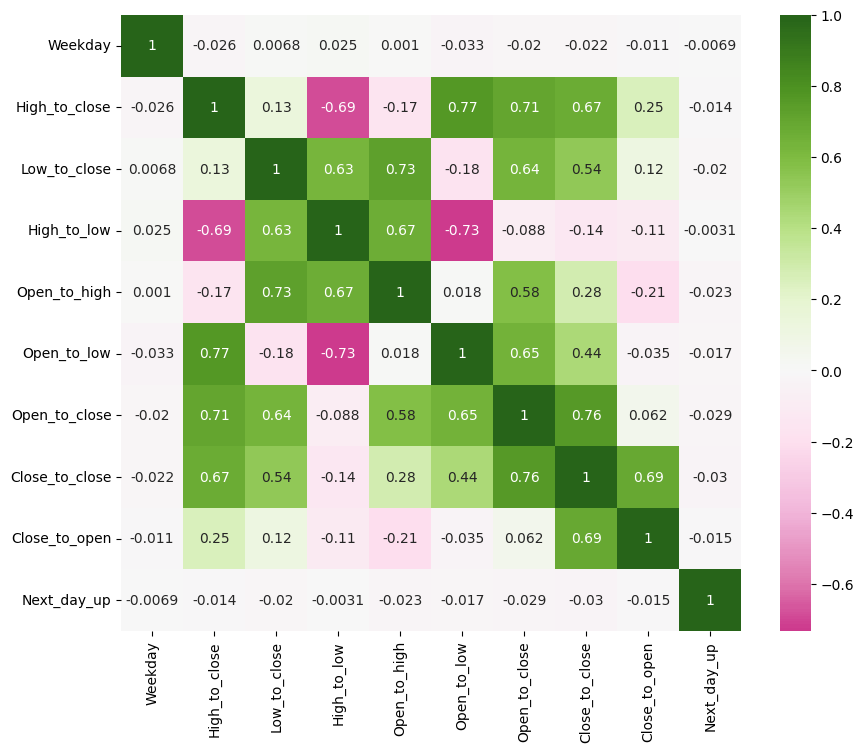

In [7]:
# heatmap of all data

plt.figure(figsize=(10,8))
sns.heatmap(all_train.corr(), cmap='PiYG', center=0, annot=True)
plt.show()

Analysis of the above: all correlations with the target ('Next_day_up') are very low, with |3%| being the highest

In [8]:
display(df[TARGET].value_counts(normalize=True))

Next_day_up
1    0.543936
0    0.456064
Name: proportion, dtype: float64

Analysis of the above: target class is fairly evenly split

# 5. MODEL: Logistic regression

In [9]:
from sklearn.metrics import confusion_matrix, accuracy_score

def get_t_f_p_n(CM):
    '''
    Get true positive rate, etc from confusion matrix
    '''
    TN = CM[0][0]
    FN = CM[1][0]
    TP = CM[1][1]
    FP = CM[0][1]
    
    return TP, FP, TN, FN, TP / (TP + FN), TN / (TN + FP)

def update_summary_table(summary_table, model_name, y_test, y_pred):
    
    conf_matrix = confusion_matrix(y_test, y_pred)
    TP, FP, TN, FN, TPR, TNR = get_t_f_p_n(conf_matrix)
    accuracy = accuracy_score(y_test, y_pred)
    
    summary_table.at[model_name, 'TP'] = TP
    summary_table.at[model_name, 'FP'] = FP
    summary_table.at[model_name, 'TN'] = TN
    summary_table.at[model_name, 'FN'] = FN
    summary_table.at[model_name, 'accuracy'] = accuracy
    summary_table.at[model_name, 'TPR'] = TPR
    summary_table.at[model_name, 'TNR'] = TNR

    print(model_name, 'metrics')
    print('accuracy:', accuracy)
    print('TPR:', TPR)
    print('TNR:', TNR)
    
    return summary_table

In [10]:
summary_results = pd.DataFrame()

In [11]:
from sklearn.linear_model import LogisticRegression

# fit logistic regression
log_reg = LogisticRegression(random_state=1, class_weight='balanced')
log_reg.fit(X_train, y_train)

# compute prediction probabilities
y_proba = pd.DataFrame(log_reg.predict_proba(X_test))

# assign class labels and final prediction column
y_proba.loc[y_proba[1]>=y_proba[0], 'prediction'] = 1
y_proba.loc[y_proba[1]<y_proba[0], 'prediction'] = 0
y_pred = y_proba['prediction']

# obtain summary
summary_results = update_summary_table(summary_results, 'logistic regression', y_test, y_pred)

logistic regression metrics
accuracy: 0.49801324503311256
TPR: 0.5206812652068127
TNR: 0.47093023255813954


# 6. MODEL: K-nearest neighbors

Accuracy for k=5: 51.126%
Accuracy for k=10: 49.669%
Accuracy for k=20: 50.464%
Accuracy for k=40: 52.185%
Accuracy for k=80: 52.185%


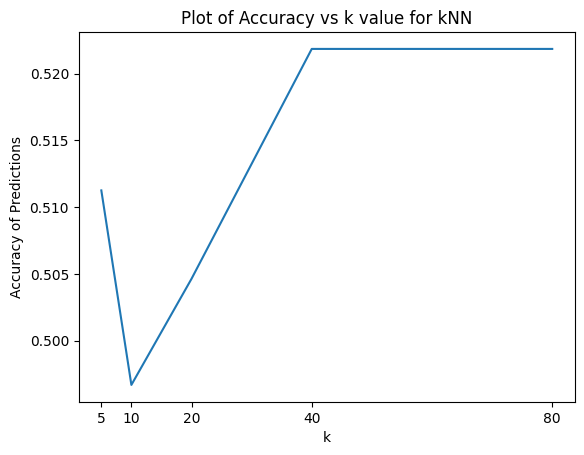

In [12]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# find the best k
k_list = [5, 10, 20, 40, 80]#, 160, 320, 480, 640, 1280]
accuracy_dict = {k: 0 for k in k_list}

# feature scaling
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)
    
# loop through k and get accuracy
for k in k_list:
    classifier = KNeighborsClassifier(n_neighbors=k)
    classifier.fit(X_train_sc, y_train)
    y_pred = classifier.predict(X_test_sc)
    accuracy_dict[k] = accuracy_score(y_test, y_pred)

for k, a in accuracy_dict.items():
    print(f'Accuracy for k={k}: {round(a*100, 3)}%')
    
# plot accuracy graph
ax = plt.axes()
ax.set_xticks(k_list)
plt.plot(list(accuracy_dict.keys()), list(accuracy_dict.values()))
plt.xlabel("k")
plt.ylabel("Accuracy of Predictions")
plt.title("Plot of Accuracy vs k value for kNN")
plt.show()

Choose k=40

In [13]:
k = 40

# feature scaling
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# fit knn
classifier = KNeighborsClassifier(n_neighbors=k)
classifier.fit(X_train_sc, y_train)
y_pred = classifier.predict(X_test_sc)
accuracy_dict[k] = accuracy_score(y_test, y_pred)

# obtain summary
summary_results = update_summary_table(summary_results, 'kNN', y_test, y_pred)

kNN metrics
accuracy: 0.5218543046357615
TPR: 0.7201946472019465
TNR: 0.28488372093023256


# 7. MODEL: Naive bayes

In [14]:
from sklearn.naive_bayes import GaussianNB

# create and fit model
model = GaussianNB()
model.fit(X_train,y_train)

# predict on test set
y_pred = model.predict(X_test)

# obtain summary
summary_results = update_summary_table(summary_results, 'naive bayes', y_test, y_pred)

naive bayes metrics
accuracy: 0.5390728476821192
TPR: 0.8710462287104623
TNR: 0.14244186046511628


# 8. MODEL: Decision tree

In [15]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# create and fit model
tree_clf = DecisionTreeClassifier(random_state=1)
tree_clf.fit(X_train, y_train)

importances = pd.DataFrame({'importance': tree_clf.feature_importances_, 'feature': X_train.columns}).sort_values('importance', ascending=False)
display(importances.head())

# predict on test set
y_pred = tree_clf.predict(X_test)

# obtain summary
summary_results = update_summary_table(summary_results, 'decision tree', y_test, y_pred)

,importance,feature
8,0.172696,Close_to_open
2,0.149064,Low_to_close
4,0.141448,Open_to_high
7,0.137124,Close_to_close
1,0.105237,High_to_close


decision tree metrics
accuracy: 0.5390728476821192
TPR: 0.5936739659367397
TNR: 0.4738372093023256


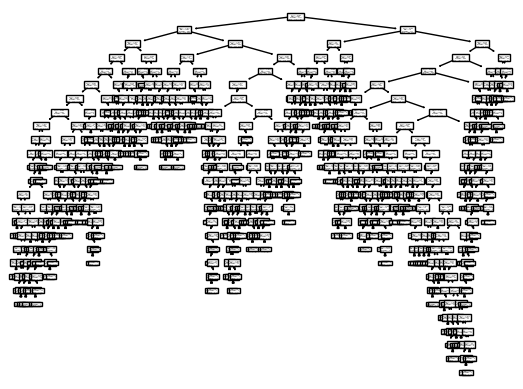

In [16]:
plot_tree(tree_clf.fit(X_train, y_train))
plt.show()

Analysis of the above: depth of 26, might be too much (overfitting)? Out of curiosity, try limiting max depth to number of features (9):

,importance,feature
8,0.181438,Close_to_open
2,0.152167,Low_to_close
1,0.127609,High_to_close
4,0.126480,Open_to_high
7,0.125504,Close_to_close


decision tree metrics
accuracy: 0.5536423841059602
TPR: 0.6909975669099757
TNR: 0.38953488372093026


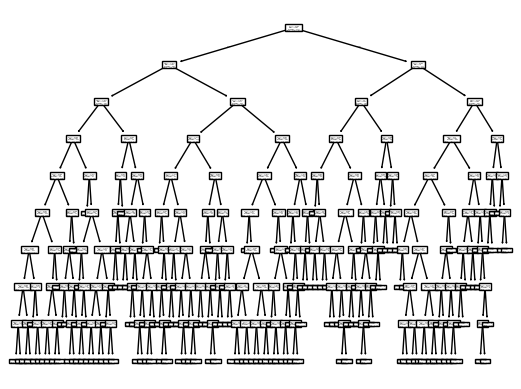

In [17]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# create and fit model
tree_clf = DecisionTreeClassifier(random_state=1, max_depth=len(FEATURES))
tree_clf.fit(X_train, y_train)

importances = pd.DataFrame({'importance': tree_clf.feature_importances_, 'feature': X_train.columns}).sort_values('importance', ascending=False)
display(importances.head())

# predict on test set
y_pred = tree_clf.predict(X_test)

# obtain summary
summary_results = update_summary_table(summary_results, 'decision tree', y_test, y_pred)

plot_tree(tree_clf.fit(X_train, y_train))
plt.show()

Analysis of the above: in doing so, accuracy is marginally improved and TPR is improved but at the cost of a worsened TNR

# 9. MODEL: Random forest

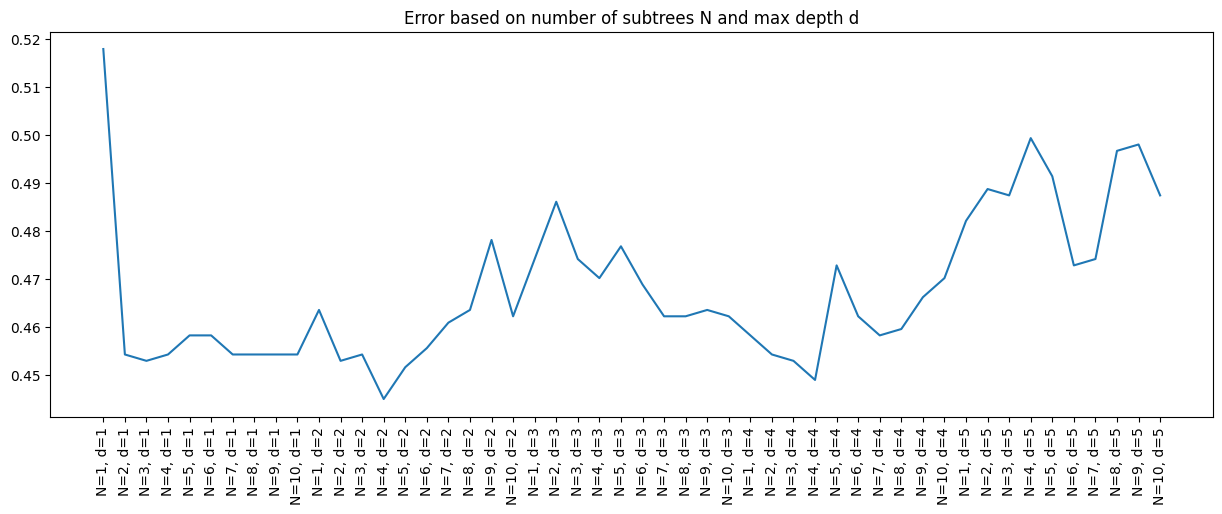

In [18]:
from sklearn.ensemble import RandomForestClassifier

# find the best N and d
errors_dict = {}

for d in range(1, 6):
    for N in range(1, 11):
        
        # create and fit model
        rnd_clf = RandomForestClassifier(n_estimators=N, max_depth=d, random_state=1)
        rnd_clf.fit(X_train, y_train)

        # predict on test set
        y_pred = rnd_clf.predict(X_test)

        # compute error (1 - accuracy)
        errors_dict[f'N={N}, d={d}'] = 1 - accuracy_score(y_test, y_pred)
        
# plot errors
plt.figure(figsize=(15, 5))
plt.errorbar(errors_dict.keys(), errors_dict.values())
plt.xticks(rotation=90)
plt.title('Error based on number of subtrees N and max depth d')
plt.show()

Choose N=4, d=2 (lowest error)

In [19]:
N = 4
d = 2

# create and fit model
rnd_clf = RandomForestClassifier(n_estimators=N, max_depth=d, random_state=1)
rnd_clf.fit(X_train, y_train)

# predict on test set
y_pred = rnd_clf.predict(X_test)

# obtain summary
summary_results = update_summary_table(summary_results, 'random forest', y_test, y_pred)

random forest metrics
accuracy: 0.5549668874172186
TPR: 0.9732360097323601
TNR: 0.055232558139534885


# 10. MODEL: Support vector machine

In [20]:
from sklearn.svm import SVC

# create and fit model
svm_clf = SVC(random_state=1)
svm_clf.fit(X_train, y_train)

# predict on test set
y_pred = model.predict(X_test)

# obtain summary
summary_results = update_summary_table(summary_results, 'support vector machine', y_test, y_pred)

support vector machine metrics
accuracy: 0.5390728476821192
TPR: 0.8710462287104623
TNR: 0.14244186046511628


# 11. Summary table

In [21]:
summary_results

,TP,FP,TN,FN,accuracy,TPR,TNR
logistic regression,214.0,182.0,162.0,197.0,0.498013,0.520681,0.470930
kNN,296.0,246.0,98.0,115.0,0.521854,0.720195,0.284884
naive bayes,358.0,295.0,49.0,53.0,0.539073,0.871046,0.142442
decision tree,284.0,210.0,134.0,127.0,0.553642,0.690998,0.389535
random forest,400.0,325.0,19.0,11.0,0.554967,0.973236,0.055233
support vector machine,358.0,295.0,49.0,53.0,0.539073,0.871046,0.142442
